In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
sys.path.append("/Users/ana/Desktop/takarada/")
from helpers_takarada import * 
from module_takarada import *
import matplotlib
import seaborn as sns
plt.rcParams.update({'savefig.dpi':300, 'axes.labelweight':'normal'})
matplotlib.rcParams['axes.linewidth'] = 0.8
from matplotlib import rc
preamble = r'''\usepackage{physics} \usepackage{upgreek} \usepackage{bm}'''
plt.rc('text.latex', preamble=preamble)
rc('text', usetex=True)

plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['figure.figsize'] = (6,4)
plt.rcParams['legend.fontsize'] = 12

''' numerical parameters for the self-consistent calculation '''
parameters1 = {'n_pass' : 1e-4,
'epsilon_threshold' : 1e-6,
'N_epsilon' : 5,
'maxiter' : 500,
'eps_last' : 1e-6,
'dmu' : 0.7,
'mix2' : 0.001,
'mix3' : 1.5,
'faktor1' : 0.1,
'max_trials' : 15,
'eps0' : 0.03,
}

parameters2 = {'n_pass' : 1e-3,
'epsilon_threshold' : 1e-6,
'N_epsilon' : 5,
'maxiter' : 100,
'eps_last' : 1e-6,
'dmu' : 0.7,
'mix2' : 0.001,
'mix3' : 1.5,
'faktor1' : 0.1,
'max_trials' : 15,
'eps0' : 0.03,
}

def colorFader(c1, c2, mix=0.5):
    c1 = np.array(matplotlib.colors.to_rgb(c1))
    c2 = np.array(matplotlib.colors.to_rgb(c2))
    return matplotlib.colors.to_hex((1-mix)*c1 + mix*c2)

def get_palette_hex(palette_name, N):
    return sns.color_palette(palette_name, n_colors=N).as_hex()

((0.6693192550746313-1.9229247100877033e-18j),
 (0.12244248998710555+4.884016368417177e-18j),
 1.8541853422844374)

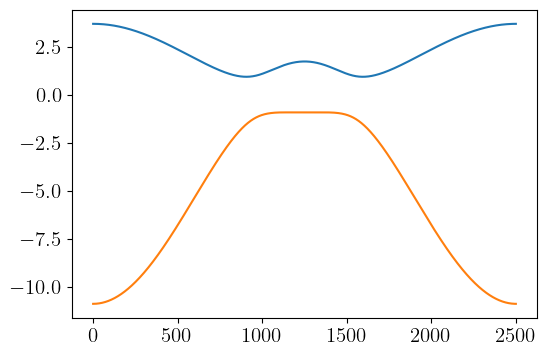

In [2]:
''' 1. generate ground state of some excitonic insulator model '''
a = 1.
b = 0.2

t12 = 0.3
delta = 0.0

t = 3.0
t_ = 1.0
Vb = 3.0
Vc = 1.0

mu0 = 0.
include_hartree = True

Nk = 2500

#gap = -3
#epsilon = 0.5*(gap + 2*t_ + 2*t)
#epsilon_ = epsilon

epsilon = 2.0
epsilon_ = 2.0

phys_parameters = [b, t, t_, t12, epsilon, epsilon_, Vb, Vc, delta]
m = model(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree)
m.GS()
plt.plot(m.energije[1]-m.mu)
plt.plot(m.energije[0]-m.mu)
m.delta_b, m.delta_c, m.gap


In [3]:
''' 2. heat up to a low temperature '''
beta0 = 50
scale = 1.005
betas = beta0/scale**np.arange(1,3)
stops = [int(np.emath.logn(scale, beta0/beta)) for beta in betas]
Ts = 1/betas
maxbrentq = 20

# set parameters below to random values, because I will not compute transport coefficients in this temperature sweep
Nomega, eps, Gammas = 1000, 1e-5, [0.01]

m.run_Tdependence(betas, stops, Gammas, Nomega, eps, maxbrentq, evaluate_transport=False)

started
0.0
49.75124378109453 8.494714611728682e-07 1.0 0.6693194700114204 0.12244245179124394
0.5
49.50372515531796 8.495544441822211e-07 1.0 0.6693194700225198 0.1224424517893033


In [5]:
rhos, thetas = rho_operators(m.K, m.phys_parameters, m.include_hartree)

''' 3. simulate pulz for excitonic susceptibility '''
perturbation_operator = rhos[2]
measure_provider = [rhos[0], rhos[1], rhos[2], rhos[3],]# rhos[4], rhos[5], rhos[6], rhos[7]]

#[rhos[1], rhos[2], rhos[5], rhos[6]]

A0 = 0.003
t0 = 2.0
sigma = 0.01
Omega0 = 0.0
dt = 0.004
t_max = 350
Ncorr = 100
tol = 1e-5

Gamma = 0.0

do_freeze = True
time, measurement, norma, delta_bs, delta_cs = simulate_pulz(m.K, m.hk0, m.rho, m.phys_parameters, m.include_hartree, perturbation_operator, measure_provider,
                                                             A0, t0, sigma, Omega0, dt, t_max, do_freeze, Ncorr, tol, m.geom, m.phases, m.g_ffts, Gamma)

do_freeze = False
timeN, measurementN, normaN, delta_bsN, delta_csN = simulate_pulz(m.K, m.hk0, m.rho, m.phys_parameters, m.include_hartree, perturbation_operator, measure_provider,
                                                             A0, t0, sigma, Omega0, dt, t_max, do_freeze, Ncorr, tol, m.geom, m.phases, m.g_ffts, Gamma)


''' 4. simulate pulz with current '''
perturbation_operator = m.tok
measure_provider = m.tok

do_freeze = True
timeJ, measurementJ, normaJ, delta_bsJ, delta_csJ = simulate_pulz(m.K, m.hk0, m.rho, m.phys_parameters, m.include_hartree, perturbation_operator, measure_provider,
                                                             A0, t0, sigma, Omega0, dt, t_max, do_freeze, Ncorr, tol, m.geom, m.phases, m.g_ffts, Gamma)

do_freeze = False
timeNJ, measurementNJ, normaNJ, delta_bsNJ, delta_csNJ = simulate_pulz(m.K, m.hk0, m.rho, m.phys_parameters, m.include_hartree, perturbation_operator, measure_provider,
                                                             A0, t0, sigma, Omega0, dt, t_max, do_freeze, Ncorr, tol, m.geom, m.phases, m.g_ffts, Gamma)

0.0
0.0005714285714285715
0.001142857142857143
0.0017142857142857142
0.002285714285714286
0.002857142857142857
0.0034285714285714284
0.004
0.004571428571428572
0.005142857142857143
0.005714285714285714
0.006285714285714286
0.006857142857142857
0.0074285714285714285
0.008
0.008571428571428572
0.009142857142857144
0.009714285714285713
0.010285714285714285
0.010857142857142857
0.011428571428571429
0.012
0.012571428571428572
0.013142857142857144
0.013714285714285714
0.014285714285714285
0.014857142857142857
0.015428571428571429
0.016
0.01657142857142857
0.017142857142857144
0.017714285714285714
0.018285714285714287
0.018857142857142857
0.019428571428571427
0.02
0.02057142857142857
0.021142857142857144
0.021714285714285714
0.022285714285714287
0.022857142857142857
0.023428571428571427
0.024
0.02457142857142857
0.025142857142857144
0.025714285714285714
0.026285714285714287
0.026857142857142857
0.027428571428571427
0.028
0.02857142857142857
0.029142857142857144
0.029714285714285714
0.03028571

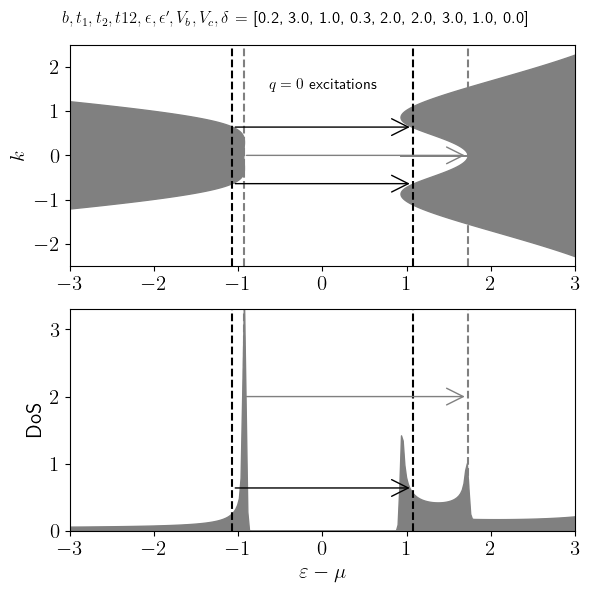

In [154]:
epsilons = np.linspace(-3,3,300)
tok_tilde = operator_tilde(m.tok, m.vecs)
dos = DoS(m.K, m.energije, epsilons, m.mu, tok_tilde, 1.0)

fig, ax = plt.subplots(nrows=2, figsize=(6,6))
gap = np.min(m.energije[1]) - np.max(m.energije[0])

ax[0].fill_between(m.energije[0] - m.mu, m.K, color='grey')
ax[0].fill_between(m.energije[1] - m.mu, m.K, color='grey')
ax[1].fill_between(epsilons, np.zeros(epsilons.shape), dos[0], color='grey')
ax[1].fill_between(epsilons, np.zeros(epsilons.shape), dos[1], color='grey')

import scipy
vrh1 = epsilons[scipy.signal.argrelextrema(dos[0], np.greater)]
vrh2 = epsilons[scipy.signal.argrelextrema(dos[1], np.greater)]

ind = np.argmin(np.abs(m.energije[1] - m.energije[0]))
k0 = m.K[ind]
dE_1 = m.energije[1,ind] - m.energije[0,ind]
dE_2 = m.energije[1,m.Nk//2] - m.energije[0,m.Nk//2]

for j in range(2):
    ax[j].axvline(m.energije[0,ind] - m.mu, ls='dashed', color='black')
    ax[j].axvline(m.energije[1,ind] - m.mu, ls='dashed', color='black')
    ax[j].axvline(m.energije[0,m.Nk//2] - m.mu, ls='dashed', color='grey')
    ax[j].axvline(m.energije[1,m.Nk//2] - m.mu, ls='dashed', color='grey')
    ax[j].annotate(
        "",                 # no text
        xy=(m.energije[0,ind] - m.mu, k0),           # arrow tip
        xytext=(m.energije[1,ind] - m.mu, k0),       # arrow tail
        arrowprops=dict(arrowstyle="<-", color='black', lw=1, mutation_scale=30)
    )
    ax[j].annotate(
        "",                 # no text
        xy=(m.energije[0,ind] - m.mu, m.K[m.Nk - ind]),           # arrow tip
        xytext=(m.energije[1,ind] - m.mu, m.K[m.Nk - ind]),       # arrow tail
        arrowprops=dict(arrowstyle="<-", color='black', lw=1, mutation_scale=30)
    )
    if j == 0:
        y = 0
    else:
        y = 2
    ax[j].annotate(
        "",                 # no text
        xy=(m.energije[0,m.Nk//2] - m.mu, y),           # arrow tip
        xytext=(m.energije[1,m.Nk//2] - m.mu, y),       # arrow tail
        arrowprops=dict(arrowstyle="<-", color='grey', lw=1, mutation_scale=30)
    )

for j in range(2):
    ax[j].set_xlim(epsilons[0], epsilons[-1])
ax[1].set_xlabel(r'$\varepsilon - \mu$', fontsize=15)
ax[0].set_ylabel(r'$k$', fontsize=15)
ax[1].set_ylabel(r'$\text{DoS}$', fontsize=15)
ax[0].set_ylim(-2.5,2.5)
ax[1].set_ylim(0,3.3)
ax[0].text(0,1.5, r'$q=0$ excitations', ha='center', fontsize=11)
fig.suptitle(rf"$b, t_1, t_2, t12, \epsilon, \epsilon', V_b, V_c, \delta$ = {phys_parameters}")
plt.tight_layout()
plt.savefig('slika0.pdf')

In [4]:
''' 5. precompute bubbles '''
Gamma = 0.008
mu_ = m.mu / Gamma
invt = Gamma / m.Ts[-1]

L = 1000
deg = 5000
nodes, weights = np.polynomial.legendre.leggauss(deg)

omegas = np.linspace(0.01,5.0,500)
Pi_w = np.zeros((len(omegas),2,2,2,m.Nk), dtype=np.complex128)
Pi_eps_w = np.zeros_like(Pi_w, dtype=np.complex128)

for i, omega in enumerate(omegas):
    pi_w, pi_eps_w = Pi_bubble_tilde_w(m.Nk, omega, m.energije, Gamma, mu_, invt, L, nodes, weights)
    Pi_w[i] = pi_w
    Pi_eps_w[i] = pi_eps_w

In [168]:
''' 4. compute excitonic susceptibitiliy via RPA '''
rhos, thetas = rho_operators(m.K, m.phys_parameters, m.include_hartree)
thetas = -thetas
rhos_tilde = operator_tilde(rhos, m.vecs)
tok_tilde = operator_tilde(m.tok, m.vecs)
Nop = len(thetas)
I = np.eye(Nop)

determinants = np.zeros(len(omegas), dtype=np.complex128)

Chi_full = np.zeros((Nop,Nop,len(omegas)), dtype=np.complex128)
Chi0 = np.zeros_like(Chi_full, dtype=np.complex128)
Chi_jj0 = np.zeros(len(omegas), dtype=np.complex128)
Chi_jrho = np.zeros((Nop, len(omegas)), dtype=np.complex128)
Chi_rhoj = np.zeros_like(Chi_jrho, dtype=np.complex128)
dChi_jj = np.zeros_like(Chi_jj0, dtype=np.complex128)

for om, omega in enumerate(omegas):
    chi0 = np.zeros((Nop, Nop), dtype=np.complex128)
    pi_w, pi_eps_w = Pi_w[om], Pi_eps_w[om]
    for i in range(Nop):
        for j in range(Nop):
            chi0[i,j] = chi_UV(m.Nk, rhos_tilde[i], rhos_tilde[j], pi_w, pi_eps_w)
    Chi0[:,:,om] = chi0

    Chi_jj0[om] = chi_UV(m.Nk, tok_tilde, tok_tilde.conj(), pi_w, pi_eps_w)

    for i in range(Nop):
        Chi_jrho[i,om] = chi_UV(m.Nk, tok_tilde, rhos_tilde[i], pi_w, pi_eps_w)
        Chi_rhoj[i,om] = chi_UV(m.Nk, rhos_tilde[i], tok_tilde.conj(), pi_w, pi_eps_w)

    mat = I - chi0 @ np.diag(thetas)
    inv = LA.inv(mat)
    determinants[om] = LA.det(mat)

    Chi_full[:,:,om] = inv @ chi0

    dChi_jj[om] = Chi_jrho[:,om] @ inv @ np.diag(thetas) @ Chi_rhoj[:,om]

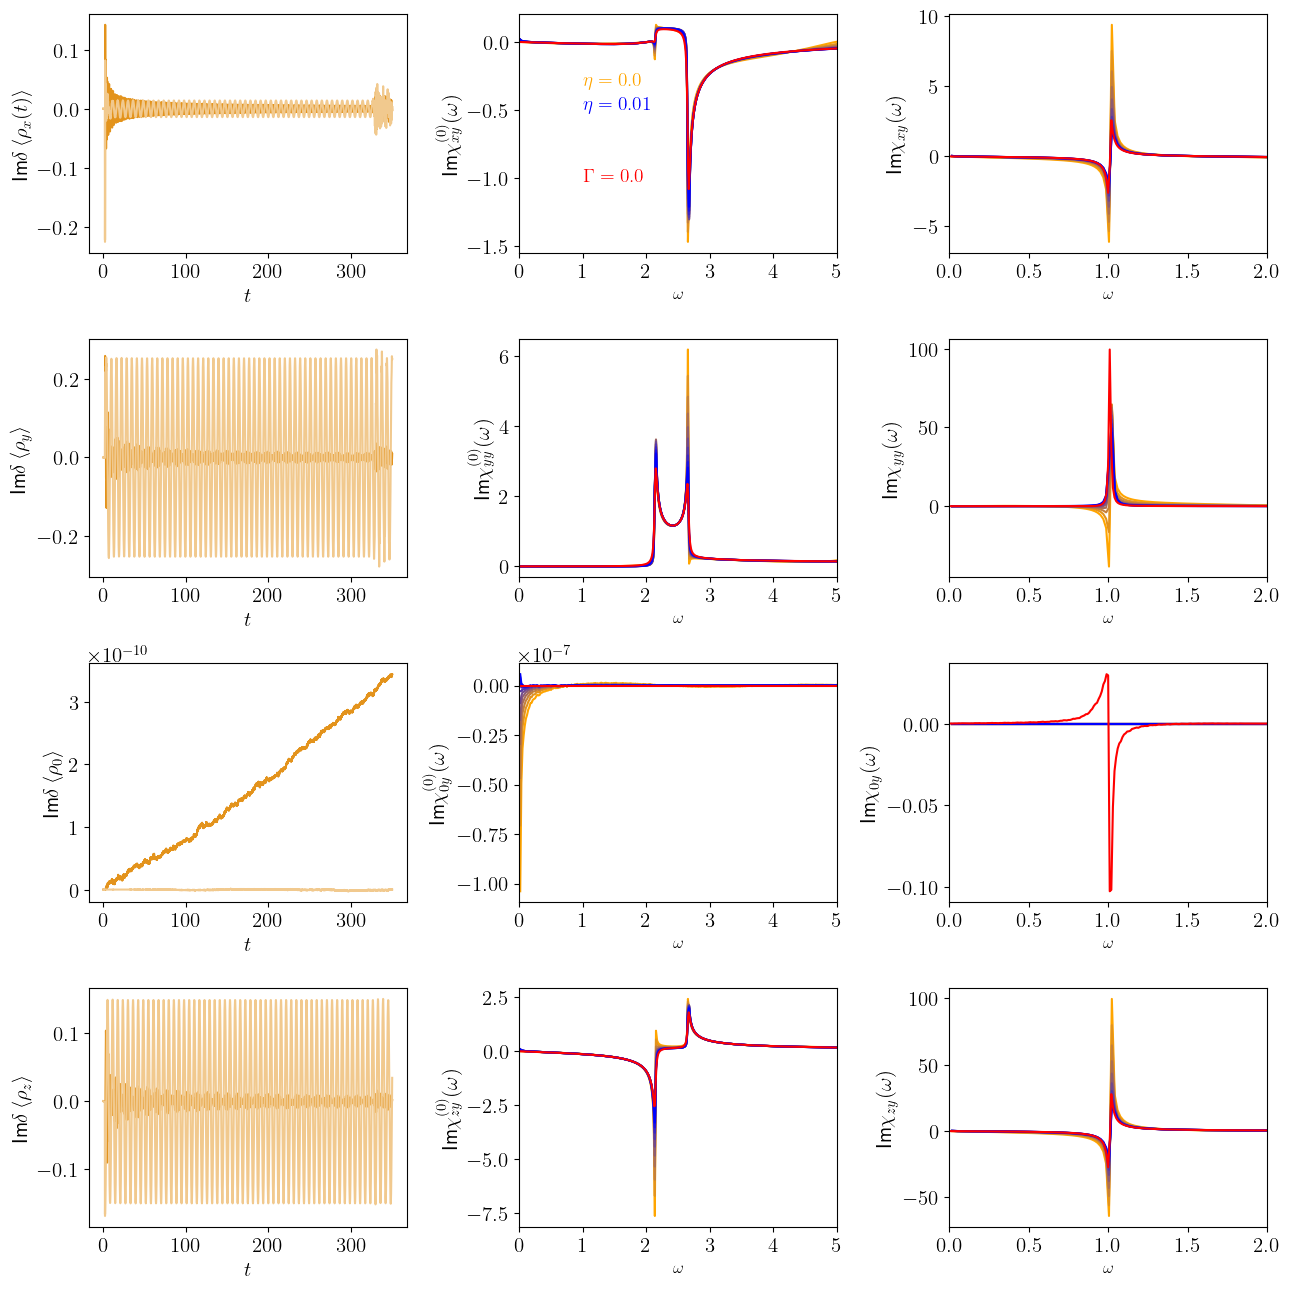

In [169]:
etas = np.linspace(0,1e-2,10)
pulz = A_pulz(time, A0, t0, sigma, Omega0)
omega_cut = 5
#omegas = np.linspace(0.01,5.0,500)


meas_0y = measurement[:,0] - measurement[0,0]
meas_0yN = measurementN[:,0] - measurementN[0,0]

meas_xy = measurement[:,1] - measurement[0,1]
meas_xyN = measurementN[:,1] - measurementN[0,1]

meas_yy = measurement[:,2] - measurement[0,2]
meas_yyN = measurementN[:,2] - measurementN[0,2]

meas_zy = measurement[:,3] - measurement[0,3]
meas_zyN = measurementN[:,3] - measurementN[0,3]

fig, ax = plt.subplots(ncols=3, nrows=4, figsize=(13,13))
for i, eta in enumerate(etas):
    Omega, Signal_xy, Pulz = susceptibility(time, meas_xy, pulz, eta, omega_cut, m.Nk)
    _, Signal_xyN, _ = susceptibility(timeN, meas_xyN, pulz, eta, omega_cut, m.Nk)
    Chi_xy = Signal_xy / Pulz
    Chi_xyN = Signal_xyN / Pulz

    _, Signal_0y, _ = susceptibility(time, meas_0y, pulz, eta, omega_cut, m.Nk)
    _, Signal_0yN, _ = susceptibility(time, meas_0yN, pulz, eta, omega_cut, m.Nk)
    Chi_0y = Signal_0y / Pulz
    Chi_0yN = Signal_0yN / Pulz

    _, Signal_yy, _ = susceptibility(time, meas_yy, pulz, eta, omega_cut, m.Nk)
    _, Signal_yyN, _ = susceptibility(time, meas_yyN, pulz, eta, omega_cut, m.Nk)
    Chi_yy = Signal_yy / Pulz
    Chi_yyN = Signal_yyN / Pulz

    _, Signal_zy, _ = susceptibility(time, meas_zy, pulz, eta, omega_cut, m.Nk)
    _, Signal_zyN, _ = susceptibility(time, meas_zyN, pulz, eta, omega_cut, m.Nk)
    Chi_zy = Signal_zy / Pulz
    Chi_zyN = Signal_zyN / Pulz

    col = colorFader('orange', 'blue', i / (len(etas) - 1))
    if i ==1:
        ax[0,0].plot(time, meas_xy.real, color=col)
        ax[0,0].plot(time, meas_xyN.real, color=colorFader(col, 'white', 0.5))
    ax[0,1].plot(Omega, Chi_xy.imag, color=col)
    ax[0,2].plot(Omega, Chi_xyN.imag, color=col)

    ax[1,1].plot(Omega, -Chi_yy.imag, color=col)
    ax[1,2].plot(Omega, -Chi_yyN.imag, color=col)
    if i ==1:
        ax[1,0].plot(time, meas_yy.real, color=col)
        ax[1,0].plot(time, meas_yyN.real, color=colorFader(col, 'white', 0.5))

    ax[2,1].plot(Omega, -Chi_0y.imag, color=col)
    ax[2,2].plot(Omega, -Chi_0yN.imag, color=col)
    if i == 1:
        ax[2,0].plot(time, meas_0y.real, color=col)
        ax[2,0].plot(time, meas_0yN.real, color=colorFader(col, 'white', 0.5))
    
    ax[3,1].plot(Omega, Chi_zy.imag, color=col)
    ax[3,2].plot(Omega, Chi_zyN.imag, color=col)
    if i == 1:
        ax[3,0].plot(time, meas_zy.real, color=col)
        ax[3,0].plot(time, meas_zyN.real, color=colorFader(col, 'white', 0.5))
chi_xy0 = Chi0[1,2]
chi_yy0 = Chi0[2,2]
chi_xy = Chi_full[1,2]
chi_yy = Chi_full[2,2]

chi_0y0 = Chi0[0,2]
chi_zy0 = Chi0[3,2]
chi_0y = Chi_full[0,2]
chi_zy = Chi_full[3,2]
ax[0,1].plot(omegas, -(chi_xy0.conj()).imag, color='red')
ax[1,1].plot(omegas, -(chi_yy0.conj()).imag, color='red')
ax[0,2].plot(omegas, -(chi_xy.conj()).imag, color='red')
ax[1,2].plot(omegas, -(chi_yy.conj()).imag, color='red')
ax[2,1].plot(omegas, -(chi_0y0.conj()).imag, color='red')
ax[3,1].plot(omegas, -(chi_zy0.conj()).imag, color='red')
ax[2,2].plot(omegas, -(chi_0y.conj()).imag, color='red')
ax[3,2].plot(omegas, -(chi_zy.conj()).imag, color='red')

for i in range(4):
    for j in range(1,3):
        ax[i,j].set_xlabel('$\omega$', fontsize=12)
        ax[i,j].set_xlim(0,5.0)

ax[0,1].set_ylabel(r'$\text{Im}\chi_{xy}^{(0)}(\omega)$', fontsize=15)
ax[1,1].set_ylabel(r'$\text{Im}\chi_{yy}^{(0)}(\omega)$', fontsize=15)
ax[0,2].set_ylabel(r'$\text{Im}\chi_{xy}(\omega)$', fontsize=15)
ax[1,2].set_ylabel(r'$\text{Im}\chi_{yy}(\omega)$', fontsize=15)


ax[2,1].set_ylabel(r'$\text{Im}\chi_{0y}^{(0)}(\omega)$', fontsize=15)
ax[3,1].set_ylabel(r'$\text{Im}\chi_{zy}^{(0)}(\omega)$', fontsize=15)
ax[2,2].set_ylabel(r'$\text{Im}\chi_{0y}(\omega)$', fontsize=15)
ax[3,2].set_ylabel(r'$\text{Im}\chi_{zy}(\omega)$', fontsize=15)

ax[0,1].text(0.2, 0.7, rf'$\eta = {np.round(etas[0],5)}$', transform=ax[0,1].transAxes, color='orange', fontsize=14)
ax[0,1].text(0.2, 0.6, rf'$\eta = {np.round(etas[-1],5)}$', transform=ax[0,1].transAxes, color='blue', fontsize=14)
ax[0,1].text(0.2,0.3, rf'$\Gamma={Gamma}$', transform=ax[0,1].transAxes, color='red', fontsize=14)
for j in range(4):
    ax[j,0].set_xlabel(r'$t$', fontsize=15)
ax[0,0].set_ylabel(r'$\text{Im} \delta \expval{\rho_x(t)}$', fontsize=15)
ax[1,0].set_ylabel(r'$\text{Im}\delta  \expval{\rho_y}$', fontsize=15)
ax[2,0].set_ylabel(r'$\text{Im}\delta  \expval{\rho_0}$', fontsize=15)
ax[3,0].set_ylabel(r'$\text{Im}\delta  \expval{\rho_z}$', fontsize=15)

ax[0,2].set_xlim(0,2)
ax[1,2].set_xlim(0,2)
ax[2,2].set_xlim(0,2)
ax[3,2].set_xlim(0,2)
plt.tight_layout()

plt.savefig('slika1.pdf')

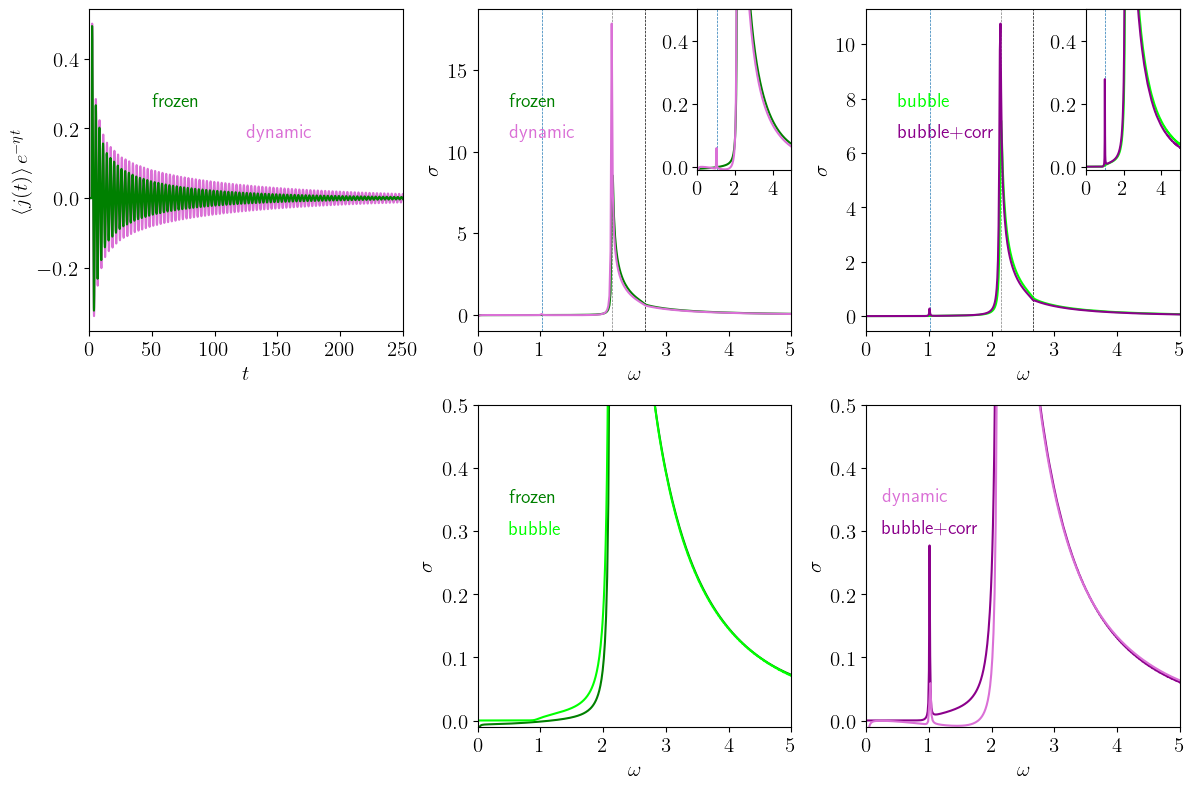

In [171]:
fig, ax = plt.subplots(ncols=3, nrows=2, figsize=(12,8))
gap = np.min(m.energije[1]) - np.max(m.energije[0])

measJ = measurementJ[:,0].real - measurementJ[0,0].real
measNJ = measurementNJ[:,0].real - measurementNJ[0,0].real

pulz = A_pulz(timeJ, A0, t0, sigma, Omega0)
omega_cut = 5
eta = 0.009

Omega, Sigma = optical_conductivity(timeJ, measJ, pulz, eta, omega_cut, m.Nk)
_, SigmaN = optical_conductivity(timeJ, measNJ, pulz, eta, omega_cut, m.Nk)

ins1 = ax[0,1].inset_axes([0.7,0.5,0.3,0.5])
ins2 = ax[0,2].inset_axes([0.7,0.5,0.3,0.5])

ax[0,0].plot(timeNJ, measJ * np.exp(-eta * timeNJ), color='green', label='frozen')
ax[0,0].plot(timeNJ, measNJ * np.exp(-eta * timeNJ), color='orchid', zorder=-100, label='dynamic')

ax[0,1].plot(Omega, Sigma, color='green'), ins1.plot(Omega, Sigma, color='green')
ax[1,1].plot(Omega, Sigma, color='green')

ax[0,1].plot(Omega, SigmaN, color='orchid'), ins1.plot(Omega, SigmaN, color='orchid')
ax[1,2].plot(Omega, SigmaN, color='orchid')
ins1.set_ylim(-0.01,0.5)

ax[0,2].plot(omegas, Chi_jj0.imag / omegas, color='lime'), ins2.plot(omegas, Chi_jj0.imag / omegas, color='lime')
ax[1,1].plot(omegas, Chi_jj0.imag / omegas, color='lime')
ax[0,2].plot(omegas, dChi_jj.imag / omegas + Chi_jj0.imag / omegas, color='darkmagenta'), ins2.plot(omegas, dChi_jj.imag / omegas + Chi_jj0.imag / omegas, color='darkmagenta')
ax[1,2].plot(omegas, dChi_jj.imag / omegas + Chi_jj0.imag / omegas, zorder=-100, color='darkmagenta')
ins2.set_ylim(-0.01,0.5)

ax[0,0].set_xlabel(r'$t$', fontsize=15)
ax[0,0].set_ylabel(r'$\expval{j(t)}e^{-\eta t}$', fontsize=15)
for i in range(2):
    ax[0,1+i].set_xlabel(r'$\omega$', fontsize=15)
    ax[1,1+i].set_xlabel(r'$\omega$', fontsize=15)
    ax[0,1+i].set_xlim(0,5)
    ax[1,1+i].set_xlim(0,5)
ax[0,0].set_xlim(0,250)

omega_max1 = Omega[np.argmax(SigmaN[:100])]
omega_max2 = Omega[np.argmax(SigmaN)]

omega_max1_ = omegas[np.argmax((dChi_jj.imag / omegas + Chi_jj0.imag / omegas)[:150])]
omega_max2_ = omegas[np.argmax((dChi_jj.imag / omegas + Chi_jj0.imag / omegas))]

ax[0,1].axvline(omega_max1, ls='dashed', zorder=-100, lw=0.5), ins1.axvline(omega_max1, ls='dashed', zorder=-100, lw=0.5)

ax[0,2].axvline(omega_max1_, ls='dashed', zorder=-100, lw=0.5), ins2.axvline(omega_max1_, ls='dashed', zorder=-100, lw=0.5)

for j in range(1,3):
    ax[0,j].axvline(dE_1, color='grey', ls='dashed', zorder=-100, lw=0.5)
    ax[0,j].axvline(dE_2, color='black', ls='dashed', zorder=-100, lw=0.5)

for j in range(2):
    for i in range(1,3):
        ax[j,i].set_ylabel(r'$\sigma$', fontsize=15)

ax[1,2].set_ylim(-0.01,0.5)
ax[1,1].set_ylim(-0.01,0.5)
ins1.set_xlim(0,5), ins2.set_xlim(0,5)

ax[0,0].text(0.2, 0.7, rf'frozen', transform=ax[0,0].transAxes, color='green', fontsize=14)
ax[0,0].text(0.5, 0.6, rf'dynamic', transform=ax[0,0].transAxes, color='orchid', fontsize=14)

ax[0,1].text(0.1, 0.7, rf'frozen', transform=ax[0,1].transAxes, color='green', fontsize=14)
ax[0,1].text(0.1, 0.6, rf'dynamic', transform=ax[0,1].transAxes, color='orchid', fontsize=14)

ax[0,2].text(0.1, 0.7, rf'bubble', transform=ax[0,2].transAxes, color='lime', fontsize=14)
ax[0,2].text(0.1, 0.6, rf'bubble+corr', transform=ax[0,2].transAxes, color='darkmagenta', fontsize=14)

ax[1,1].text(0.1,0.7, rf'frozen', transform=ax[1,1].transAxes, color='green', fontsize=14)
ax[1,1].text(0.1,0.6, rf'bubble', transform=ax[1,1].transAxes, color='lime', fontsize=14)

ax[1,2].text(0.05,0.7, rf'dynamic', transform=ax[1,2].transAxes, color='orchid', fontsize=14)
ax[1,2].text(0.05,0.6, rf'bubble+corr', transform=ax[1,2].transAxes, color='darkmagenta', fontsize=14)

ins1.set_xticks([0,2,4]), ins2.set_xticks([0,2,4])
ax[1,0].axis('off')
plt.tight_layout()
plt.savefig('slika2.pdf')

In [158]:
dChi_jj[0].imag / omegas[0], Chi_jj0[0].imag / omegas[0]

(3.6319454804585603e-07, 4.078999479451427e-05)

In [ ]:
def second_derivative_central(f, h):
    fpp = (f[:-2] - 2*f[1:-1] + f[2:]) / h**2
    return fpp

drude = 0.0
for orb in range(2):
    d2e_dk2 = second_derivative_central(m.energije[orb], m.K[1] - m.K[0])
    fermi_dirac = fd(m.energije[orb], m.mu, m.Ts[-1])
    drude += np.sum(d2e_dk2 * fermi_dirac[1:-1])

kinetic = parameters(b, t, t_, t12, Vb, Vc, delta)[1]
D = drude_weight(m.K, m.vecs, m.energije, m.mu, m.Ts[-1], kinetic).real
D / m.Nk * np.pi / 2, integral_omega(Chi_jj0.imag / omegas, omegas)

(2.3811176633174984, 1.8294184163672482)

In [15]:
''' check that rhos, thetas reconstruct the HF Hamiltonian '''
hartreefock = h_k(m.K, m.hk0, m.rho, m.phys_parameters, 0.0, m.include_hartree) - m.hk0
hartreefock0 = np.zeros_like(hartreefock)

rhos, thetas = rho_operators(m.K, m.phys_parameters, m.include_hartree)
rhos_tilde = operator_tilde(rhos, m.vecs)

for nu in range(len(thetas)):
    th = thetas[nu]
    rho = rhos[nu]
    rho_tilde = rhos_tilde[nu]
    suma = 0.0
    for band in range(2):
        for k in range(m.Nk):
            suma += fd(m.energije[band,k], m.mu, m.Ts[-1]) * rho_tilde[band,band,k]
    hartreefock0 += th / m.Nk * suma * rho

np.allclose(hartreefock, hartreefock0)


True

In [18]:
measJ = measurementJ[:,0].real - measurementJ[0,0].real
measNJ = measurementNJ[:,0].real - measurementNJ[0,0].real

pulz = A_pulz(timeJ, A0, t0, sigma, Omega0)
omega_cut = 20

etas = np.linspace(0.001,0.01,10)

fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(10,7))

for i, eta in enumerate(etas):
    Omega, Signal_jj, Pulz = susceptibility(timeJ, measJ, pulz, eta, omega_cut, m.Nk)
    _, Signal_jjN, _ = susceptibility(timeJ, measNJ, pulz, eta, omega_cut, m.Nk)
    col = colorFader('orange', 'blue', i / (len(etas) - 1))
    Chi_jj = Signal_jj / Pulz
    Chi_jjN = Signal_jjN / Pulz
    for j in range(2):
        ax[0,j].plot(Omega, -Chi_jj.imag / Omega, color=col)
        ax[1,j].plot(Omega, -Chi_jjN.imag / Omega, color=col)

#plt.ylim(-0.1,1)
col = 'red'
for j in range(2):
    ax[0,j].plot(omegas, chi_jj.imag / omegas, color=col, label=Gammas[g],)
    ax[1,j].plot(omegas, chi_jj.imag / omegas + dchi_jj.imag / omegas, color=col, label=Gammas[g])
ax[0,1].set_ylim(0,5)
for j in range(2):
    ax[0,j].set_ylabel(r'$\sigma^{(0)}(\omega)$')
    ax[1,j].set_ylabel(r'$\sigma(\omega)$')
    for i in range(2):
        ax[j,i].set_xlim(0,5)
        ax[j,i].set_xlabel('$\omega$', fontsize=12)
ax[0,1].set_ylim(0,1.5)
ax[1,1].set_ylim(0,1.5)
ax[0,0].set_ylim(0,20)
ax[1,0].set_ylim(0,20)

plt.tight_layout()
plt.savefig('slika1-1.pdf')

NameError: name 'measurementJ' is not defined

In [172]:
def drude_weight(K, vecs, energije, mu, T, kinetic):
    Nk = len(K)
    Norb = energije.shape[0]
    #build first and second derivatives of kinetic Hamiltonian
    dH_dk = np.zeros_like(vecs, dtype=np.complex128)
    d2H_dk2 = np.zeros_like(vecs, dtype=np.complex128)
    for line in kinetic:
        x, orb1, orb2, t = line
        x, orb1, orb2, t = float(x), int(orb1), int(orb2), float(t)
        dH_dk[orb1,orb2] += -1j * t * x * np.exp(-1j*K*x)
        d2H_dk2[orb1,orb2] += - t * x**2 * np.exp(-1j*K*x)
    dH_dk_rotate = operator_tilde(dH_dk, vecs)
    d2H_dk2_rotate = operator_tilde(d2H_dk2, vecs)
    drude = 0.0
    for k in range(Nk):
        for orb in range(Norb):
            suma_k = 0.0
            suma_k += d2H_dk2_rotate[orb,orb,k]
            for orb_ in range(Norb):
                if orb != orb_:
                    suma_k += np.abs(dH_dk_rotate[orb_,orb,k])**2 / (energije[orb,k] - energije[orb_,k])
            drude += suma_k * fd(energije[orb,k], mu, T)
    return drude

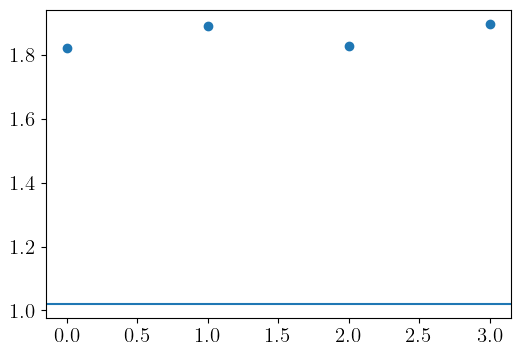

In [176]:
kinetic = parameters(b, t, t_, t12, Vb, Vc, delta)[1]

D = drude_weight(m.K, m.vecs, m.energije, m.mu, m.Ts[-1], kinetic)


LHS = np.trapz(Sigma, Omega)
LHS_N = np.trapz(SigmaN, Omega)
RHS = D / m.Nk * np.pi / 2

lhs0 = np.trapz(Chi_jj0.imag / omegas, omegas)
lhs = np.trapz(Chi_jj0.imag / omegas + dChi_jj.imag / omegas, omegas)

plt.scatter(range(4), [LHS, LHS_N, lhs0, lhs])
plt.axhline(RHS.real)

0.5639332501522087 3.2249503405956848


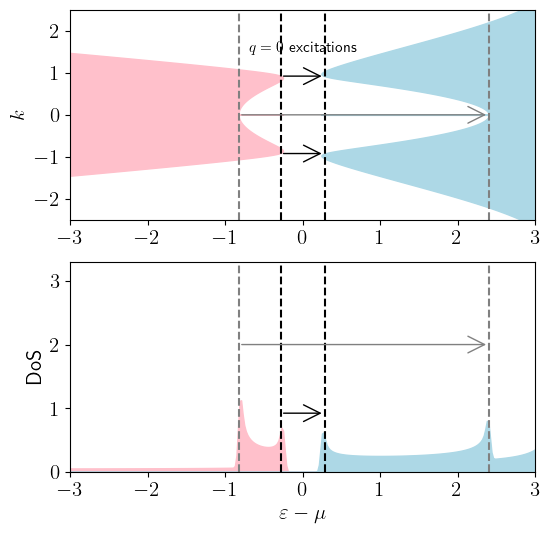

In [132]:
import scipy
def DoS(K, energije, epsilons, mu, tok_tilde, faktor, shape='Gaussian'):
    Nk = len(K)
    v_max = np.max(np.abs(tok_tilde))
    sigma = np.sqrt(v_max * (epsilons[1] - epsilons[0]) * (K[1] - K[0])) * faktor
    dos = np.zeros((2, len(epsilons)))
    for k in prange(Nk):
        for alpha in range(2):
            dos[alpha] += delta_approximation(epsilons - energije[alpha,k] + mu, sigma, shape) 
    return dos / Nk

epsilons = np.linspace(-3,3,300)
tok_tilde = operator_tilde(m.tok, m.vecs)
dos = DoS(m.K, m.energije, epsilons, m.mu, tok_tilde, 1.0)

fig, ax = plt.subplots(nrows=2, figsize=(6,6))
gap = np.min(m.energije[1]) - np.max(m.energije[0])

ax[0].fill_between(m.energije[0] - m.mu, m.K, color='pink')
ax[0].fill_between(m.energije[1] - m.mu, m.K, color='lightblue')
ax[1].fill_between(epsilons, np.zeros(epsilons.shape), dos[0], color='pink')
ax[1].fill_between(epsilons, np.zeros(epsilons.shape), dos[1], color='lightblue')

vrh1 = epsilons[scipy.signal.argrelextrema(dos[0], np.greater)]
vrh2 = epsilons[scipy.signal.argrelextrema(dos[1], np.greater)]

ind = np.argmin(np.abs(m.energije[1] - m.energije[0]))
k0 = m.K[ind]
dE_1 = m.energije[1,ind] - m.energije[0,ind]
dE_2 = m.energije[1,m.Nk//2] - m.energije[0,m.Nk//2]

for j in range(2):
    ax[j].axvline(m.energije[0,ind] - m.mu, ls='dashed', color='black')
    ax[j].axvline(m.energije[1,ind] - m.mu, ls='dashed', color='black')
    ax[j].axvline(m.energije[0,m.Nk//2] - m.mu, ls='dashed', color='grey')
    ax[j].axvline(m.energije[1,m.Nk//2] - m.mu, ls='dashed', color='grey')
    ax[j].annotate(
        "",                 # no text
        xy=(m.energije[0,ind] - m.mu, k0),           # arrow tip
        xytext=(m.energije[1,ind] - m.mu, k0),       # arrow tail
        arrowprops=dict(arrowstyle="<-", color='black', lw=1, mutation_scale=30)
    )
    ax[j].annotate(
        "",                 # no text
        xy=(m.energije[0,ind] - m.mu, m.K[m.Nk - ind]),           # arrow tip
        xytext=(m.energije[1,ind] - m.mu, m.K[m.Nk - ind]),       # arrow tail
        arrowprops=dict(arrowstyle="<-", color='black', lw=1, mutation_scale=30)
    )
    if j == 0:
        y = 0
    else:
        y = 2
    ax[j].annotate(
        "",                 # no text
        xy=(m.energije[0,m.Nk//2] - m.mu, y),           # arrow tip
        xytext=(m.energije[1,m.Nk//2] - m.mu, y),       # arrow tail
        arrowprops=dict(arrowstyle="<-", color='grey', lw=1, mutation_scale=30)
    )

for j in range(2):
    ax[j].set_xlim(epsilons[0], epsilons[-1])
ax[1].set_xlabel(r'$\varepsilon - \mu$', fontsize=15)
ax[0].set_ylabel(r'$k$', fontsize=15)
ax[1].set_ylabel(r'$\text{DoS}$', fontsize=15)
ax[0].set_ylim(-2.5,2.5)
ax[1].set_ylim(0,3.3)
ax[0].text(0,1.5, r'$q=0$ excitations', ha='center', fontsize=11)

print(dE_1, dE_2)

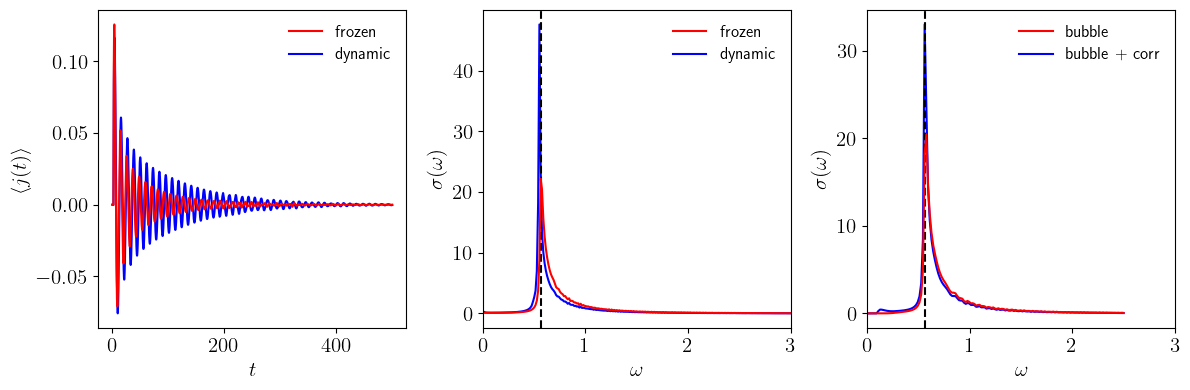

In [133]:
fig, ax = plt.subplots(ncols=3, figsize=(12,4))
gap = np.min(m.energije[1]) - np.max(m.energije[0])

measJ = measurementJ[:,0].real - measurementJ[0,0].real
measNJ = measurementNJ[:,0].real - measurementNJ[0,0].real

pulz = A_pulz(timeJ, A0, t0, sigma, Omega0)
omega_cut = 5
eta = 0.01

Omega, Sigma = optical_conductivity(timeJ, measJ, pulz, eta, omega_cut, m.Nk)
_, SigmaN = optical_conductivity(timeJ, measNJ, pulz, eta, omega_cut, m.Nk)

ax[0].plot(timeNJ, measJ * np.exp(-eta * timeNJ), color='red', label='frozen')
ax[0].plot(timeNJ, measNJ * np.exp(-eta * timeNJ), color='blue', zorder=-100, label='dynamic')
#ax[0].set_xlim(0,200)
ax[0].set_xlabel(r'$t$', fontsize=15)
ax[0].set_ylabel(r'$\langle{j(t)\rangle}$', fontsize=15)

ax[1].plot(Omega, Sigma, color='red', label='frozen',)# ls='dashed')
ax[1].plot(Omega, SigmaN, color='blue', label='dynamic',zorder=-100)# ls='dashed')

for j in range(2):
    ax[1].set_xlim(0,4)

sigma_x = chi_jj.imag / omegas
dsigma_x = dchi_jj.imag / omegas 

g = 2
ax[2].plot(omegas, sigma_x[g], color='red', label='bubble')
ax[2].plot(omegas, sigma_x[g] + dsigma_x[g], color='blue', label='bubble + corr', zorder=-100)

for j in range(3):
    ax[j].legend(frameon=False)

for j in range(1,3):
    ax[j].set_xlabel(r'$\omega$', fontsize=15)
    ax[j].set_ylabel(r'$\sigma(\omega)$', fontsize=15)
    ax[j].set_xlim(0,3)
    ax[j].axvline(dE_1, color='black', zorder=-100, ls='dashed')
    ax[j].axvline(dE_2, color='grey', zorder=-100, ls='dashed')
#ax[1].set_ylim(0,0.3)
pal = get_palette_hex('viridis', len(Gammas))

#ax[2].plot(ena, 1000 * np.imag(dve / tri))


#ax[1].set_ylim(0,0.3)
#ax[2].set_ylim(0,2)


plt.tight_layout()

#for g, Gamma in enumerate(Gammas):
#    if g > 1: ax[2].plot(omegas / gap, sigma_x[g] + dsigma_x[g], color=pal[g])

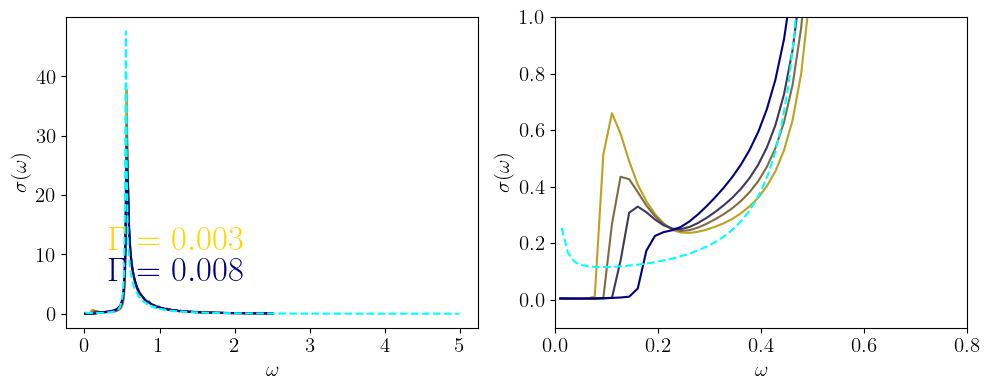

In [104]:
pal = [colorFader('gold', 'navy', i / (len(Gammas) - 1)) for i in range(len(Gammas))]
fig, ax = plt.subplots(ncols=2, figsize=(10,4))
for g, Gamma in enumerate(Gammas):
    if g > 0:
        for j in range(2):
            ax[j].plot(omegas, sigma_x[g] +dsigma_x[g], color=pal[g])
ax[1].set_ylim(-0.1,1), ax[1].set_xlim(0,0.8)
for j in range(2):
    ax[j].set_xlabel(r'$\omega$', fontsize=15)
    ax[j].set_ylabel(r'$\sigma(\omega)$', fontsize=15)
for j in range(2):
    ax[j].plot(Omega, SigmaN, color='cyan', label='dynamic', ls='dashed')

ax[0].text(0.1,0.25, rf'$\Gamma={Gammas[0]}$', color=pal[0],transform=ax[0].transAxes, fontsize=25)
ax[0].text(0.1,0.15, rf'$\Gamma={Gammas[-1]}$', color=pal[-1],transform=ax[0].transAxes, fontsize=25)

plt.tight_layout()


In [47]:
''' 4. calculate chi from RPA '''
tok_tilde = operator_tilde(m.tok, m.vecs)
rhos, thetas = rho_operators(m.K, m.phys_parameters, m.include_hartree)
rhos_tilde = operator_tilde(rhos, m.vecs)

m1,m2,m3,m4 = compute_all_mf_matrices(m.K, m.rho, m.geom, m.phases, m.g_ffts)
mat_tilde = operator_tilde(m1+m2+m3+m4, m.vecs)

L = 30
deg = 1000
nodes, weights = np.polynomial.legendre.leggauss(deg)

Gammas = np.logspace(-4,-1,20)
omegas0 = np.logspace(-5,-1,20)

sigma_x0 = np.zeros((len(Gammas), len(omegas0)))
dsigma_x0 = np.zeros_like(sigma_x0)

for g, Gamma in enumerate(Gammas):
    print(g)
    mu_ = m.mu / Gamma
    invt = Gamma / m.Ts[-1]
    for om, omega in enumerate(omegas0):
        results = chi_jrho2(m.Nk, len(thetas), tok_tilde, rhos_tilde, mat_tilde, -thetas, m.energije, mu_, invt, omega, Gamma, L, nodes, weights)
        sigma_x0[g,om] = results['j_j'].imag / omega
        dsigma_x0[g,om] = results['dj_j'].imag / omega

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


In [45]:
epsilons = np.linspace(-1,1,50)
m.tok_tilde = operator_tilde(m.tok, m.vecs)
mfd1 = -fd_1(epsilons, m.Ts[-1])
L11s = np.zeros(len(Gammas))
for g, Gamma in enumerate(Gammas):
    print(g)
    L11 = m.ls_kubo(epsilons, Gamma, mfd1)[0]
    L11s[g] = L11

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


NameError: name 'sigma_x0' is not defined

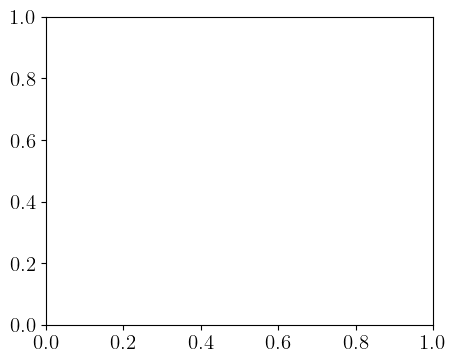

In [135]:
pal = [colorFader('gold', 'navy', i / (len(Gammas) - 1)) for i in range(len(Gammas))]
fig, ax = plt.subplots(figsize=(5,4))
for g, Gamma in enumerate(Gammas):
    if g > 2:
        plt.scatter(Gamma, sigma_x0[g,0], color=pal[g])
        plt.scatter(Gamma, sigma_x0[g,0] + dsigma_x0[g,0], color=pal[g], marker='x')
plt.xscale('log')

plt.scatter(Gammas, L11s, color='red', s=5, label='')
plt.yscale('log')

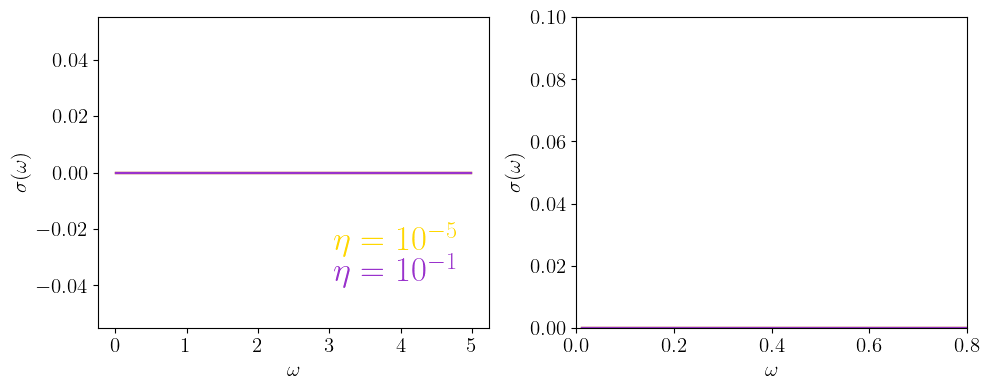

In [49]:
etas = np.linspace(1e-5, 1e-1,10)
fig, ax = plt.subplots(ncols=2, figsize=(10,4))

pal = [colorFader('gold', 'darkorchid', i / (len(etas) - 1)) for i in range(len(etas))]
meas = measurement[:,0].real - measurement[0,0].real
measN = measurementN[:,0].real - measurementN[0,0].real

pulz = A_pulz(time, A0, t0, sigma, Omega0)

for i, eta in enumerate(etas):
    Omega, Sigma = optical_conductivity(time, meas, pulz, eta, omega_cut, m.Nk)
    _, SigmaN = optical_conductivity(time, measN, pulz, eta, omega_cut, m.Nk)
    for j in range(2):
        ax[j].plot(Omega, SigmaN, color=pal[i])
ax[1].set_ylim(0,0.1), ax[1].set_xlim(0,0.8)

ax[0].text(0.6,0.25, r'$\eta=10^{-5}$', color=pal[0],transform=ax[0].transAxes, fontsize=25)
ax[0].text(0.6,0.15, r'$\eta=10^{-1}$', color=pal[-1],transform=ax[0].transAxes, fontsize=25)

for j in range(2):
    ax[j].set_xlabel(r'$\omega$', fontsize=15)
    ax[j].set_ylabel(r'$\sigma(\omega)$', fontsize=15)

plt.tight_layout()